adjust METHOD_OPTIONS to limit maximum iteration number, as the comparison with [v1]

In [1]:
%load_ext autotime

# ── 0. Imports & path setup ─────────────────────────────────────────
import sys, os, copy, time, warnings
# sys.path.insert(0, "/home/niels/FELsim_clone/backend")
CURRENT_DIR = os.getcwd()
BACKEND_DIR = CURRENT_DIR if os.path.basename(CURRENT_DIR) == "backend" else os.path.abspath(os.path.join(CURRENT_DIR, "../backend"))
sys.path.insert(0, BACKEND_DIR)
print(BACKEND_DIR)
os.makedirs(os.path.join(CURRENT_DIR, "../results"), exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from ebeam import beam as ebeam_class
from beamline import lattice
from excelElements import ExcelElements
from beamOptimizer import beamOptimizer
from evolutionPlotter import EvolutionPlotter
from felsimAdapter import FELsimAdapter

# ── Shared constants ─────────────────────────────────────────────────
# EXCEL_PATH     = "/home/niels/FELsim_clone/beam_excel/Beamline_elements_3.xlsx"
# EXCEL_PATH     = "/home/niels/FELsim_clone/beam_excel/Beamline_elements_3.xlsx"
EXCEL_PATH  = os.path.abspath(os.path.join(CURRENT_DIR, "../beam_excel/Beamline_elements_3.xlsx"))


BEAM_ENERGY    = 40.0    # MeV
N_PARTICLES    = 1000
SEED           = 42
CURRENT_BOUNDS = (0.01, 1.5)   # A  (lower bound > 0)

# ── Relativistic factors ─────────────────────────────────────────────
relat = lattice(1, fringeType=None)
relat.setE(E=BEAM_ENERGY)
GAMMA_REL = relat.gamma
BETA_REL  = relat.beta
NORM      = GAMMA_REL * BETA_REL

# ── Undulator matching targets (MkV FEL, K=1.2, λ_u=2.3 cm) ─────────
K        = 1.2
LAMBDA_U = 2.3e-2   # m
BETA_YM  = GAMMA_REL / (K * 2 * np.pi / LAMBDA_U)   # matched β_y at UND entrance
BETA_XM  = 1.4       # m  — matched β_x at UND entrance
ALPHA_XM = 0.47      # — Courant-Snyder α_x at UND entrance
ALPHA_YM = 0.0       # — Courant-Snyder α_y at UND entrance

print(f"γ = {GAMMA_REL:.4f},  β = {BETA_REL:.6f},  βγ = {NORM:.4f}")
print(f"Matched β_ym = {BETA_YM:.4f} m   (K={K}, λ_u={LAMBDA_U*100:.1f} cm)")
print(f"Matched β_xm = {BETA_XM:.4f} m,  α_xm = {ALPHA_XM:.4f},  α_ym = {ALPHA_YM:.4f}")


c:\Users\yilu2\my_files\research\FELsim\backend
γ = 79.2794,  β = 0.999920,  βγ = 79.2731
Matched β_ym = 0.2418 m   (K=1.2, λ_u=2.3 cm)
Matched β_xm = 1.4000 m,  α_xm = 0.4700,  α_ym = 0.0000
time: 14.5 s (started: 2026-06-03 15:01:45 -10:00)


In [2]:
import warnings

warnings.filterwarnings(
    "ignore", 
    message=".*'where' used without 'out'.*", 
    category=UserWarning, 
    module="scipy.optimize._trustregion_constr"
)

warnings.filterwarnings(
    "ignore", 
    message=".*delta_grad == 0.0.*", 
    category=UserWarning, 
    module="scipy.optimize._differentiable_functions"
)

time: 0 ns (started: 2026-06-03 15:02:00 -10:00)


## 1 — Beam Distribution
Physics-based 6D Gaussian matching the UH linac reference parameters.


In [3]:
%load_ext autotime

# ── Beam parameters ─────────────────────────────────────────────────
epsilon_n         = 8.0      # π·mm·mrad  normalised emittance
x_std             = 0.8      # mm
y_std             = 0.8      # mm
f_RF              = 2856e6   # Hz
bunch_spread_ps   = 2.0      # ps
energy_spread_pct = 0.5      # %
h                 = 5e9      # 1/s  chirp

epsilon     = epsilon_n / NORM
x_prime_std = epsilon / x_std
y_prime_std = epsilon / y_std
tof_std     = bunch_spread_ps * 1e-9 * f_RF
energy_std  = energy_spread_pct * 10

ebeam_obj = ebeam_class()
PARTICLES = ebeam_obj.gen_6d_gaussian(
    0,
    [x_std, x_prime_std, y_std, y_prime_std, tof_std, energy_std],
    N_PARTICLES
)
# Apply longitudinal chirp
PARTICLES[:, 5] += h * (PARTICLES[:, 4] / f_RF)

print(f"ε = {epsilon:.5f} π·mm·mrad  (geometric)")
print(f"σ_x={x_std:.2f} mm, σ_x'={x_prime_std:.5f} mrad")
print(f"σ_y={y_std:.2f} mm, σ_y'={y_prime_std:.5f} mrad")
print(f"Particles: {PARTICLES.shape}")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
ε = 0.10092 π·mm·mrad  (geometric)
σ_x=0.80 mm, σ_x'=0.12615 mrad
σ_y=0.80 mm, σ_y'=0.12615 mrad
Particles: torch.Size([1000, 6])
time: 47 ms (started: 2026-06-03 15:02:00 -10:00)


## 2 — Beamline & Element Index Map
The `ExcelElements` parser produces **138 FELsim elements**. Key reference indices:
| Location | FELsim idx | z (m) | Physical meaning |
|---|---|---|---|
| End of 1st doublet region | 8–9 | ≈0.73–1.0 | First α targets |
| IP (focus) | 59 | ≈7.11 | Minimum envelope |
| UND entrance | 117 | ≈12.39 | Undulator matching |


In [4]:
%load_ext autotime

# ── Load beamline & map quad indices ───────────────────────────────
beamline_full = ExcelElements(EXCEL_PATH).create_beamline()
print(f"FELsim elements: {len(beamline_full)}")

s = 0.0
quad_info = []
for i, e in enumerate(beamline_full):
    cls = e.__class__.__name__
    L   = float(getattr(e, 'length', 0.0) or 0.0)
    if cls in ('qpfLattice', 'qpdLattice'):
        quad_info.append((i, cls, round(s, 5), round(s+L, 5),
                          round(float(getattr(e, 'current', 0) or 0), 5)))
    s += L

quad_indices = [q[0] for q in quad_info]
df_quads = pd.DataFrame(quad_info, columns=['idx','type','s_start','s_end','current_A'])
print(f"Quadrupoles: {len(quad_indices)}")
print(df_quads.to_string(index=False))

# ── Gold-standard currents from Eremey's FELsim S1 solution ─────────
FELSIM_S1_CURRENTS = {
     1: 0.8218,  3: 1.0430,
    10: 3.8834,
    16: 2.2396, 18: 4.9532, 20: 3.4258,
    27: 4.6657,
    33: 2.6942, 35: 2.6523, 37: 0.2768, 39: 0.2768, 41: 2.6523, 43: 2.6942,
    50: 4.6739,
    56: 3.1219, 58: 3.3129,
    61: 5.1775, 63: 4.0434,
    70: 4.6818,
    76: 3.9336, 78: 4.0787, 80: 0.0139,
    87: 1.3624, 93: 0.9452, 95: 2.8851, 97: 2.1921,
}
print(f"\nFELSIM_S1_CURRENTS: {len(FELSIM_S1_CURRENTS)} quadrupoles loaded")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
FELsim elements: 138
Quadrupoles: 26
 idx       type  s_start    s_end  current_A
   1 qpfLattice  0.35878  0.44768    0.88572
   3 qpdLattice  0.64453  0.73342    1.05289
  10 qpfLattice  2.03304  2.12194    3.81660
  16 qpdLattice  2.73535  2.82425    2.57981
  18 qpfLattice  2.86743  2.95633    4.56570
  20 qpdLattice  2.99951  3.08841    2.57981
  27 qpfLattice  3.55448  3.64338    4.49146
  33 qpdLattice  4.15187  4.24077    1.59614
  35 qpfLattice  4.29157  4.38047    3.08092
  37 qpdLattice  4.43127  4.52017    1.59614
  39 qpdLattice  4.93513  5.02403    1.59614
  41 qpfLattice  5.07483  5.16373    3.08092
  43 qpdLattice  5.21453  5.30343    1.59614
  50 qpfLattice  5.83098  5.91988    4.49072
  56 qpdLattice  6.36946  6.45836    2.25575
  58 qpfLattice  6.55775  6.64665    1.67186
  61 qpfLattice  7.32562  7.41452    0.02487
  63 qpdLattice  7.46992  7.55882    0.00100
  70 qpfLattice  8.10749

In [5]:
%load_ext autotime

# ── Confirm key reference positions ────────────────────────────────
s = 0.0
for i, e in enumerate(beamline_full):
    s += float(getattr(e, 'length', 0.0) or 0.0)
    if i in (8, 9, 15, 25, 32, 37, 55, 59, 92, 117):
        print(f"  el {i:3d}  {e.__class__.__name__:20s}  s_end={s:.5f} m")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
  el   8  dipole_wedge          s_end=1.80682 m
  el   9  driftLattice          s_end=2.03304 m
  el  15  driftLattice          s_end=2.73535 m
  el  25  dipole_wedge          s_end=3.34855 m
  el  32  driftLattice          s_end=4.15187 m
  el  37  qpdLattice            s_end=4.52017 m
  el  55  driftLattice          s_end=6.36946 m
  el  59  driftLattice          s_end=7.11013 m
  el  92  driftLattice          s_end=10.21208 m
  el 117  driftLattice          s_end=12.39158 m
time: 0 ns (started: 2026-06-03 15:02:01 -10:00)


## 3 — Statistical Benchmark Infrastructure

`run_benchmark()` runs the same scenario `N_RUNS` times from different random starting currents.  
`plot_stat_convergence()` plots **mean ± 1σ RMS bands** — the same visual style as Eremey's
reference convergence figures.


In [6]:
%load_ext autotime

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def method_label(method, label=None):
    if label:
        return label
    if isinstance(method, str):
        return method
    return getattr(method, "__name__", str(method))

# ── Benchmark runner ────────────────────────────────────────────────
def run_benchmark(scenario_name, beamline_slice_len, particles, seg_var, obj, bounds,
                  method, n_runs=5, SEED=42, seed_offset=0, jac=None, options=None, verbose=True, method_tag=None):
    """Run beamOptimizer.calc() n_runs times from uniform-random starting currents."""
    var_names = list({seg_var[i][0] for i in seg_var})
    results   = []
    method_name = method_label(method, method_tag)

    for run_i in range(n_runs):
        bl = ExcelElements(EXCEL_PATH).create_beamline()[:beamline_slice_len]
        p  = particles.clone()
        rng = np.random.default_rng(SEED + seed_offset + run_i * 997)
        sp  = {v: {"bounds": bounds[v],
                   "start": float(rng.uniform(bounds[v][0], bounds[v][1]))}
               for v in var_names}
        start_x = {v: sp[v]["start"] for v in var_names}
        obj_copy = copy.deepcopy(obj)
        opti = beamOptimizer(bl, p)
        t0   = time.perf_counter()

        try:
            res  = opti.calc(method, seg_var, sp, obj_copy, jac=jac, options=options,
                             printResults=False, plotProgress=False)
            wall = time.perf_counter() - t0

            result_x_dict = dict(zip(var_names, res.x))
            i_1 = result_x_dict.get("I", np.nan)
            i_3 = result_x_dict.get("I2", np.nan)

            def safe_get_measured(idx):
                if idx in opti.objectives and len(opti.objectives[idx]) > 0:
                    val = opti.objectives[idx][0].get("measured", np.nan)
                    return float(val.item() if hasattr(val, 'item') else val)
                return np.nan

            alpha_x = safe_get_measured(8)
            alpha_y = safe_get_measured(9)

            results.append({
                "run": run_i+1, "method": method_name, "scenario": scenario_name,
                "final_mse": float(res.fun),
                "nfev": int(getattr(res,'nfev',len(opti.plotMSE))),
                "nit": int(getattr(res,'nit',-1)),
                "wall_time": round(wall,3),
                "mse_curve": list(opti.plotMSE), "success": bool(res.success),
                "start_x": start_x, "result_x": result_x_dict,
                "I_1": i_1, "I_3": i_3, "alpha_x": alpha_x, "alpha_y": alpha_y
            })
        except Exception as exc:
            wall = time.perf_counter() - t0
            results.append({
                "run": run_i+1, "method": method_name, "scenario": scenario_name,
                "final_mse": float("nan"), "nfev": -1, "nit": -1,
                "wall_time": round(wall,3), "mse_curve": [], "success": False,
                "start_x": start_x, "result_x": {}, "error": str(exc),
                "I_1": np.nan, "I_3": np.nan, "alpha_x": np.nan, "alpha_y": np.nan
            })
            if verbose: print(f"  {method_name} run {run_i+1} FAILED: {exc}")
            continue
        if verbose:
            print(f"  {method_name:22s}  run {run_i+1}/{n_runs}  "
                  f"MSE={results[-1]['final_mse']:.3e}  nit={results[-1]['nit']:<3} "
                  f"nfev={results[-1]['nfev']:<4} t={wall:.2f}s")
    return results

def results_to_df(results_list):
    keep = ('run','method','scenario','method_tag','final_mse','nfev','nit',
            'wall_time','success', 'I_1', 'I_3', 'alpha_x', 'alpha_y')
    return pd.DataFrame([{k: r[k] for k in keep if k in r} for r in results_list])

def plot_stat_convergence(results_by_tag, title="Convergence", figsize=None,
                          colors=None, ax=None, save_path=None, scale="log",
                          convergence_epsilon=None):
    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=figsize or (7, 4.5))
    else: fig = ax.get_figure()

    # 🛠️ FIX 1: Matplotlib API Update
    try:
        cmap = plt.colormaps.get_cmap("tab10")
    except AttributeError:
        cmap = plt.get_cmap("tab10")

    if colors is None: colors = [cmap(i) for i in range(len(results_by_tag))]

    legend_handles = []
    for (tag, res_list), col in zip(results_by_tag.items(), colors):
        n_t = len(res_list)

        if convergence_epsilon is None:
            converged_iter = [r for r in res_list if r.get('mse_curve')]
        else:
            converged_iter = [r for r in res_list
                    if r.get('mse_curve')
                    and np.isfinite(r['mse_curve'][-1])
                    and r['mse_curve'][-1] < convergence_epsilon]

        n_s = len(converged_iter)
        curves = [r['mse_curve'] for r in converged_iter]

        if not curves:
            legend_handles.append(Line2D([0], [0], color=col, linewidth=2,
                                         label=f"{tag}  (0/{n_t} converged)"))
            continue

        max_len = max(len(c) for c in curves)
        padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves], dtype=np.float64)

        # 🛠️ FIX 2: clip to a positive floor so log10 is well-defined
        padded = np.clip(padded, a_min=1e-20, a_max=1e100)

        evals = np.arange(1, max_len + 1)

        log_padded = np.log10(padded)
        log_mean   = np.mean(log_padded, axis=0)
        log_std    = np.std(log_padded,  axis=0)
        mean       = 10 ** log_mean
        band_lower = 10 ** (log_mean - log_std)
        band_upper = 10 ** (log_mean + log_std)

        ax.plot(evals, mean, color=col, linewidth=2.0, zorder=3)
        ax.fill_between(evals, np.maximum(band_lower, 1e-20), band_upper,
                        color=col, alpha=0.20, zorder=2)

        legend_handles.append(Line2D([0], [0], color=col, linewidth=2,
                                     label=f"{tag}  ({n_s}/{n_t} converged)"))

    ax.set_yscale(scale)
    ax.set_xlabel('Function evaluations (Forward Passes)', fontsize=11)
    ax.set_ylabel('Normalised MSE', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(handles=legend_handles, fontsize=8, framealpha=0.9, loc='upper right')
    ax.grid(True, which='both', alpha=0.25)
    ax.tick_params(labelsize=9)
    if standalone:
        fig.tight_layout()
        if save_path: fig.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.show()
    return ax
print("Benchmark helpers loaded (Warnings Suppressed).")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Benchmark helpers loaded (Warnings Suppressed).
time: 16 ms (started: 2026-06-03 15:02:01 -10:00)


---
## 4 — Scenario A: Doublet (2 quadrupoles)

**Exact replication of Stage 1 from `beamline_optimization.ipynb`:**
α_x = α_y = 0 at elements 8–9 (s ≈ 0.73–1.0 m).

Simple 2D problem — validates all methods and compares FELsim vs COSY timing.


In [7]:
def run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_BEAMLINE_LEN, METHODS_A, SEED=42, scale="log", options=None, METHOD_OPTIONS={}):
    A_BOUNDS      = {"I": CURRENT_BOUNDS, "I2": CURRENT_BOUNDS}
    REF_I_1 = REF_I[0]
    REF_I_3 = REF_I[1]
    results_A = {}
    for method_spec in METHODS_A:
        if len(method_spec) == 3:
            method, jac, label = method_spec
        else:
            method, jac = method_spec
            label = None
        options = METHOD_OPTIONS.get(method_label(method, label), None) 
        method_name = method_label(method, label)
        tag = method_name + ("+jac" if jac else "")
        print(f"\n▶ Scenario A — {tag}  ({N_RUNS_A} runs)")

        # Execute benchmark (Note: passing 'jac' here prepares for PyTorch analytical gradients later)
        res = run_benchmark(
            "A",
            A_BEAMLINE_LEN,
            PARTICLES,
            A_VARS,
            A_OBJ,
            A_BOUNDS,
            method=method,
            n_runs=N_RUNS_A,
            SEED=SEED,
            seed_offset=0,
            jac=jac,
            options=options,
            method_tag=method_name,
        )
        for r in res:
            r["method_tag"] = tag
        results_A[tag] = res

    # Flatten and merge nested results into a single DataFrame
    df_A = results_to_df([r for v in results_A.values() for r in v])

    # ==============================================================================
    # 🎯 CORE FIX: Patch the bug where derivative-free algorithms return negative iterations
    # ==============================================================================
    # Since derivative-free algorithms lack internal line searches, their number
    # of function evaluations (nfev) is mathematically equivalent to their true exploration steps (nit).
    # If iteration count < 0 is detected, directly extract 'nfev' as the true iteration count!
    if 'nit' in df_A.columns and 'nfev' in df_A.columns:
        df_A.loc[df_A['nit'] < 0, 'nit'] = df_A.loc[df_A['nit'] < 0, 'nfev']

    print("\n" + "="*115)
    print(f" 🎯 SCENARIO A: Robustness (Tol < {EPSILON}) & Discovered Physics State vs Reference")
    print("="*115)

    # 1. Core Evaluation: Check if each run successfully converged below the target MSE threshold
    df_A['is_converged'] = df_A['final_mse'] < EPSILON

    # 2. Calculate average performance metrics
    def _geom_mean_converged(s):
        conv = s[s < EPSILON]
        return 10 ** np.log10(conv).mean() if len(conv) else np.nan
    # (🎯 Note: The redundant 'nfev_mean' has been completely removed as requested)
    summary_stats = df_A.groupby('method_tag').agg(
        conv_rate=('is_converged', 'mean'),
        nit_mean=('nit', 'mean'),
        nfev_mean=('nfev', 'mean'),
        wall_time_mean=('wall_time', 'mean'),
    ).join(
        df_A.groupby('method_tag')['final_mse']
            .apply(_geom_mean_converged)
            .rename('final_mse_mean')
    )

    # 3. Extract the Champion Solution: Find the run with the lowest error for each method,
    #    extracting its exact hardware currents and resulting alpha observables.
    idx_best = df_A.groupby('method_tag')['final_mse'].idxmin()
    best_runs = df_A.loc[idx_best, ['method_tag', 'I_1', 'I_3', 'alpha_x', 'alpha_y']].set_index('method_tag')

    # 4. Merge all statistical data
    final_summary = summary_stats.join(best_runs).reset_index()

    # Inject the expert's gold-standard values to establish the Ground Truth
    final_summary['I_1_ref'] = REF_I_1
    final_summary['I_3_ref'] = REF_I_3

    # Reorder columns: Place the AI-predicted currents right next to the expert's Reference values
    final_summary = final_summary[[
        'method_tag', 'conv_rate', 'nit_mean', 'nfev_mean', 'wall_time_mean',
        'final_mse_mean', 'I_1_ref', 'I_1', 'I_3_ref', 'I_3', 'alpha_x', 'alpha_y'
    ]]

    # 5. Plain text formatted output to bypass Jupyter HTML rendering bugs (missing tables)
    format_dict = {
        'conv_rate': '{:.0%}',
        'nit_mean': '{:.1f}',
        'nfev_mean': '{:.1f}',
        'wall_time_mean': '{:.3f} s',
        'final_mse_mean': '{:.2e}',
        'I_1_ref': '{:.4f} A',
        'I_1': '{:.4f} A',
        'I_3_ref': '{:.4f} A',
        'I_3': '{:.4f} A',
        'alpha_x': '{:.2e}',
        'alpha_y': '{:.2e}'
    }

    formatted_df = final_summary.copy()

    # Apply formatting conversions in bulk
    for col, fmt in format_dict.items():
        if col in formatted_df.columns:
            formatted_df[col] = formatted_df[col].apply(lambda x: fmt.format(x) if pd.notna(x) else "NaN")

    # Print the final beautifully aligned data table
    print(formatted_df.to_string(index=False, justify='center'))
    print("="*115)

    # Plot the final algorithm stability curve
    plot_stat_convergence(
        results_A,
        title=f"Scenario A: Convergence Stability (Target MSE < {EPSILON})",
        convergence_epsilon=EPSILON,
        scale=scale
    )
    return results_A, df_A, final_summary

time: 16 ms (started: 2026-06-03 15:02:01 -10:00)


In [8]:
%load_ext autotime
def display_results(results_A):
        
    # ── Scenario A — Best optimised quadrupole currents per method ─────
    print("─── Scenario A: Best Optimised Quadrupole Currents per Method ───")
    print(f"{'Method':<22} {'Best MSE':>12} {'I (A)':>10} {'I2 (A)':>10}")
    print("─" * 58)
    for tag, res_list in results_A.items():
        valid = [r for r in res_list
                if r.get('result_x') and not np.isnan(r['final_mse'])]
        if not valid:
            print(f"  {tag:<20}  no valid run")
            continue
        best = min(valid, key=lambda r: r['final_mse'])
        I  = best['result_x'].get('I',  float('nan'))
        I2 = best['result_x'].get('I2', float('nan'))
        print(f"  {tag:<20} {best['final_mse']:>12.4e} {I:>10.4f} {I2:>10.4f}")
    print()
    print(f"  Reference FELsim S1 currents: I={REF_I[0]:.4f} A,  I2={REF_I[1]:.4f} A")
    # Mean best across all runs
    all_valid = [r for v in results_A.values() for r in v
                if r.get('result_x') and not np.isnan(r['final_mse'])]
    if all_valid:
        best_overall = min(all_valid, key=lambda r: r['final_mse'])
        print(f"\n  Overall best across all methods/runs:")
        print(f"    Method: {best_overall['method_tag']},  MSE={best_overall['final_mse']:.4e}")
        print(f"    I={best_overall['result_x']['I']:.5f} A,  "
            f"I2={best_overall['result_x']['I2']:.5f} A")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 0 ns (started: 2026-06-03 15:02:01 -10:00)


In [9]:
CURRENT_BOUNDS = (0.01, 1.5)
EPSILON = 1e-3

REF_I_1 = 0.8218
REF_I_3 = 1.0430
REF_I = [REF_I_1, REF_I_3]

# parameter setting
N_RUNS_A = 100
A_BEAMLINE_LEN = 10

METHOD_OPTIONS = {
    "L-BFGS-B":     {'eps': 1e-4, 'maxiter': 100, 'ftol': 1e-6, 'gtol': 1e-6},
    "SLSQP":        {'eps': 1e-4, 'maxiter': 100, 'ftol': 1e-6},
    "trust-constr": {'finite_diff_rel_step': 1e-4, 'gtol': 1e-5, 'xtol': 1e-6, 'maxiter': 100},
    "Nelder-Mead":  {'maxiter': 400, 'xatol': 1e-6, 'fatol': 1e-9},
    "COBYLA":       {'maxiter': 400},
}

METHODS_A = [
    ("Nelder-Mead", None),
    ("L-BFGS-B",    "2-point"),
    ("SLSQP",       "2-point"),
    ("COBYLA",      None),
    ("trust-constr", None)
]

A_VARS = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
}
A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}



time: 0 ns (started: 2026-06-03 15:02:01 -10:00)


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

▶ Scenario A — Nelder-Mead  (100 runs)


  Nelder-Mead             run 1/100  MSE=9.792e-13  nit=55  nfev=109  t=20.11s
  Nelder-Mead             run 2/100  MSE=6.577e-13  nit=59  nfev=118  t=21.65s
  Nelder-Mead             run 3/100  MSE=1.188e-12  nit=68  nfev=130  t=22.78s
  Nelder-Mead             run 4/100  MSE=5.050e-12  nit=40  nfev=78   t=12.98s
  Nelder-Mead             run 5/100  MSE=4.183e-13  nit=56  nfev=106  t=16.99s
  Nelder-Mead             run 6/100  MSE=2.097e-12  nit=47  nfev=91   t=15.61s
  Nelder-Mead             run 7/100  MSE=2.338e-12  nit=62  nfev=117  t=20.65s
  Nelder-Mead             run 8/100  MSE=9.038e-13  nit=63  nfev=120  t=20.99s
  Nelder-Mead             run 9/100  MSE=9.655e-13  nit=201 nfev=393  t=70.41s
  Nelder-Mead             run 10/100  MSE=3.819e-12  nit=61  nfev=114  t=29.99s
  Nelder-Mead             run 11/100  MSE=1.973e-13  nit=54  nfev=103  t=28.58s
  Nelder-Mead             run 12/100  MSE=9.123e-13  nit=61  nfev=115  t=22.69s
  Nelder-Mead             run 13/100  MSE=4.305e-

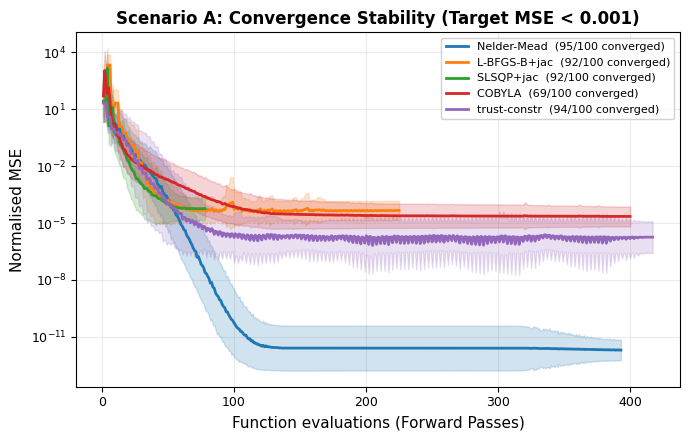

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            7.4698e-14     0.2643     0.2527
  L-BFGS-B+jac           4.2678e-07     0.7558     0.5839
  SLSQP+jac              2.0474e-07     0.7557     0.5839
  COBYLA                 1.2749e-07     0.7559     0.5840
  trust-constr           1.8941e-11     0.2643     0.2527

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=7.4698e-14
    I=0.26427 A,  I2=0.25265 A
time: 3h 32min 3s (started: 2026-06-03 15:02:01 -10:00)


In [10]:
%load_ext autotime

results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_BEAMLINE_LEN, METHODS_A,scale="log",METHOD_OPTIONS=METHOD_OPTIONS)
display_results(results_A)